In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [3]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
from joblib import dump, load
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sbn
import numpy as np

In [4]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

# eXplainable AI

Since in the model selection phase of the previous task, we have identified a RandomForestClassifier (with a specific data preprocessing step) as the best classifier for our goals, let's apply the XAI techniques to it.

## Dataset generation

Let's reconstruct the classifier.

In [5]:
from classification_utility import train_test_for_non_distance, split_in_train_and_validation

In [6]:
train_set, test_set, train_label, test_label=train_test_for_non_distance()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


In [7]:
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

In [8]:
print(f'TRAINING (Oversampled): {train_set_os.shape[0]} - {train_label_os.shape[0]}')
print(f'TEST (Oversampled): {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING (Oversampled): 672056 - 672056
TEST (Oversampled): 32586 - 32586


In [9]:
TR_set_os, VD_set_os, TR_label_os, VD_label_os=split_in_train_and_validation(train_set_os, train_label_os)
print(f'TRAINING (Oversampled): {TR_set_os.shape[0]} - {TR_label_os.shape[0]}')
print(f'VALIDATION (Oversampled): {VD_set_os.shape[0]} - {VD_label_os.shape[0]}')
print(f'TEST (Oversampled): {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING (Oversampled): 470439 - 470439
VALIDATION (Oversampled): 201617 - 201617
TEST (Oversampled): 32586 - 32586


In [10]:
#Custom function to print the classification report con training/valid
def print_report(train_label, train_predictions, validation_label, valid_predictions, v_or_t='TEST'):
    #v_or_t to print TEST or VALIDATION RESULTS
    classes=['not top20', 'top20']
    if train_label is not None:
        print('TRAINING SET RESULTS')
        print(classification_report(train_label, train_predictions, target_names=classes))
        print('--------------------')
    print(v_or_t+' SET RESULTS')
    print(classification_report(validation_label, valid_predictions, target_names=classes))

In [11]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True)
rf = rf.fit(train_set_os, train_label_os)
train_pred_rf = rf.predict(train_set_os)
test_pred_rf = rf.predict(test_set)
print_report(train_label=train_label_os, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.94      0.93    402429
       top20       0.90      0.87      0.89    269627

    accuracy                           0.91    672056
   macro avg       0.91      0.90      0.91    672056
weighted avg       0.91      0.91      0.91    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.92      0.91     28066
       top20       0.46      0.43      0.44      4520

    accuracy                           0.85     32586
   macro avg       0.68      0.67      0.68     32586
weighted avg       0.85      0.85      0.85     32586



In [12]:
# Create the SHAP explainer for the Random Forest model
rf_explainer_shap = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")

We were not able to define a TreeExplainer that performed an 'interventional perturbation' due to computational limitations. We will use only the 'tree_path_dependent' method instead.

In [13]:
# Determine the SHAP values for the test set
# shap_values = rf_explainer.shap_values(test_set)

In [14]:
# shap_values

In [15]:
# Save the SHAP values in a file
# dump(shap_values, "shap_values_distributional.joblib")

In [16]:
# Load the SHAP values from a file
shap_values = load("shap_values_distributional.joblib")

In [17]:
shap_values

array([[[ 0.0429741 , -0.0429741 ],
        [ 0.04785275, -0.04785275],
        [-0.0538742 ,  0.0538742 ],
        ...,
        [-0.02389954,  0.02389954],
        [-0.12365953,  0.12365953],
        [ 0.01558981, -0.01558981]],

       [[-0.02303124,  0.02303124],
        [-0.00204869,  0.00204869],
        [-0.0270597 ,  0.0270597 ],
        ...,
        [ 0.01619873, -0.01619873],
        [-0.07437197,  0.07437197],
        [-0.01384713,  0.01384713]],

       [[-0.01718087,  0.01718087],
        [ 0.01655121, -0.01655121],
        [-0.03020833,  0.03020833],
        ...,
        [ 0.00030146, -0.00030146],
        [-0.01070041,  0.01070041],
        [-0.00828825,  0.00828825]],

       ...,

       [[-0.00966793,  0.00966793],
        [ 0.04130594, -0.04130594],
        [-0.02794902,  0.02794902],
        ...,
        [ 0.01760635, -0.01760635],
        [ 0.04164181, -0.04164181],
        [-0.00664996,  0.00664996]],

       [[ 0.005622  , -0.005622  ],
        [ 0.02066057, -0.02

'shap_values' contains the SHAP values for every feature for each instance in your test set, so we can break down the contribution of every feature to every individual prediction.

## Global interpretability

### SHAP: SHapley Additive Explanations

In [18]:
#%pip install shap

In [19]:
shap_values_class_1 = shap_values[:, :, 1]  # SHAP contributions for the class '1'
print(shap_values_class_1.shape)
shap_values_class_0 = shap_values[:, :, 0]  # SHAP contributions for the class '0'
print(shap_values_class_0.shape)

(32586, 12)
(32586, 12)


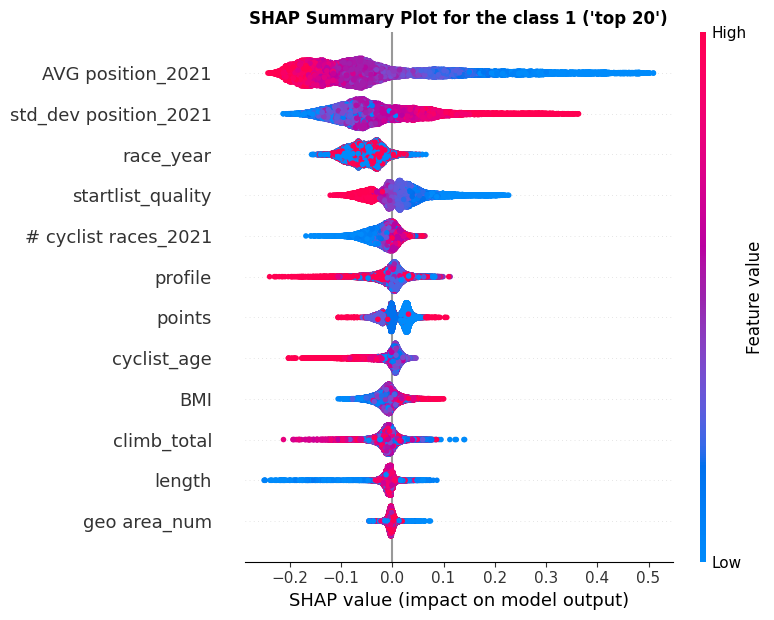

In [20]:
plt.title("SHAP Summary Plot for the class 1 ('top 20')", fontweight='bold')
shap.summary_plot(shap_values_class_1, test_set)
plt.show()
plt.close()

**SHAP Summary plot observations**
- From the SHAP summary plot we can see that the features that contribute most to the final prediction are the statistics for the races up to 2021, in particular the most influential feature is _'AVG position_2021'_. In fact, the plot shows that the instances with a very low value of AVG position have a high probability of being classified as _'top 20'_ (class 1). This is clearly an observation that makes sense, as we would expect valuable cyclists to have a low AVG position value.
- The second most impactful feature is  _'std_dev_position_2021'_ but here we have an opposite situation; for those cyclists having a lower standard deviations on their placements, there is an higher probability to be classified as _'not top 20'_ (class 0). Actually this pattern seems non sensical since we expect valuable cyclists not to have a strong variations on their placements. But on the other hand we have also to remember that most of the cyclists have performed very few races, in particular a consistent number of cyclists has only one recorded placement hence with a 0 value of std_dev.
- As for the startlist_quality feature, the lower the value, the more likely the cyclists are to be classified as top_20. This could be a reasonable result as we expect races with high values of startlist quality to attract many cyclists, thus reducing our probability of being in the top 20.

In general these 3 features are the most impactful for the model to classify the istances as 'top_20'. For the other features we notice that there is not a general trend but there are differences depending on the single instances. The 'geo area' feature is the least influent in the class assignment.

In [21]:
cyclists=pd.read_csv('../dataset/preprocessedCyclists_without_outliers.csv')

In [22]:
cyclists

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
1,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
2,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
3,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978
4,jacques-esclassan,20.916803,7,29,62,France,Europe,Western Europe,1948.0,43,6.0,7.0,36.0,NaN,4.0,27.0,39.0,NaN,34.928320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5950,ivan-raimondi,19.696783,173,173,1,Italy,Europe,Southern Europe,1969.0,173,NaN,173.0,NaN,NaN,173.0,NaN,NaN,NaN,0.000000
5951,jose-vincente-diaz,20.031931,17,17,1,Colombia,America,America,1965.0,17,NaN,17.0,NaN,NaN,17.0,NaN,NaN,NaN,0.000000
5952,jon-ander-insausti,25.450000,54,54,1,Spain,Europe,Southern Europe,1992.0,54,NaN,NaN,54.0,NaN,NaN,NaN,54.0,NaN,0.000000
5953,carlos-melero,20.011635,38,38,1,Spain,Europe,Southern Europe,1948.0,38,NaN,38.0,NaN,NaN,38.0,NaN,NaN,NaN,0.000000


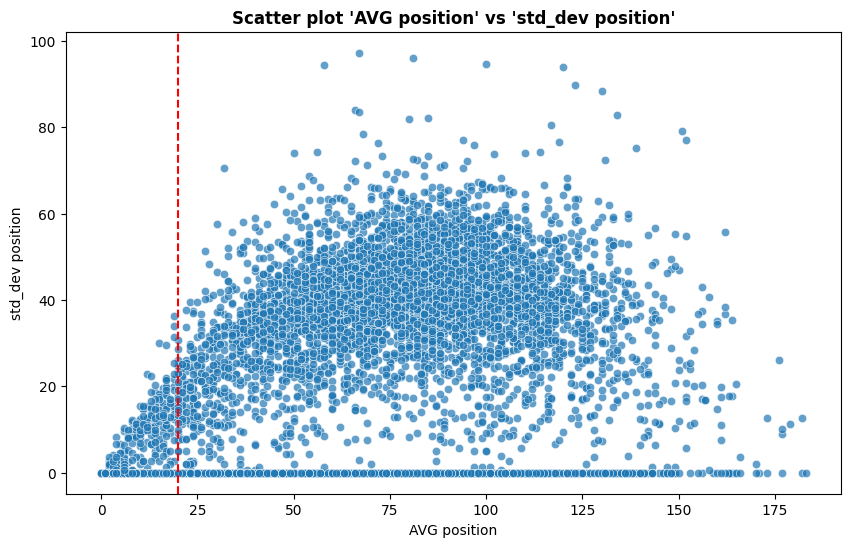

In [23]:
plt.figure(figsize=(10, 6))
sbn.scatterplot(x=cyclists["AVG position"], y=cyclists["std_dev position"], alpha=0.7)
plt.title("Scatter plot 'AVG position' vs 'std_dev position'", fontweight='bold')
plt.axvline(x=20, color='red', linestyle='--', label='AVG position = 20') 
plt.xlabel("AVG position")
plt.ylabel("std_dev position")
plt.show()
plt.close()

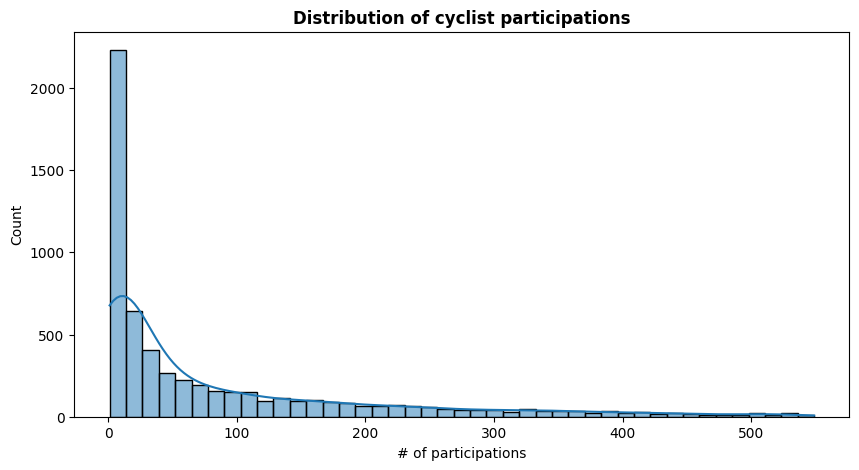

In [24]:
plt.figure(figsize=(10, 5))
sbn.histplot(cyclists['# cyclist races'], kde=True)
plt.title('Distribution of cyclist participations', fontweight='bold')
plt.xlabel('# of participations')
plt.show()
plt.close()

In [25]:
col1 = cyclists["AVG position"]
col2 = cyclists["std_dev position"]
pearson_corr = col1.corr(col2, method='pearson')
kendall_corr = col1.corr(col2, method='kendall')
spearman_corr = col1.corr(col2, method='spearman')
print(f"Pearson Correlation: {pearson_corr:.3f}")
print(f"Kendall Correlation: {kendall_corr:.3f}")
print(f"Spearman Spearman: {spearman_corr:.3f}")

Pearson Correlation: 0.292
Kendall Correlation: 0.192
Spearman Spearman: 0.271


Even if the correlation indices are not high, we can see from the scatter plot that a higher average position typically implies a higher std_dev, but the variability is not linearly proportional to the avg position. We can also observe that there are cyclists with an average position < 20 who have quite high variability in the placements. 
This counterintuitive result coming from the SHAP values analysis is probably due to the fact that in our dataset most of the cyclists have only one race recorded in the dataset, causing a '0' value for the standard deviation.

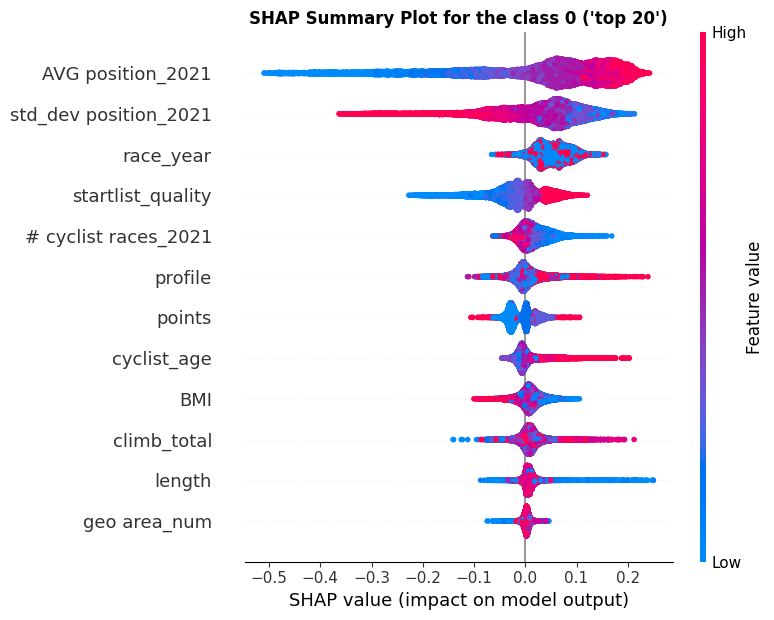

In [26]:
plt.title("SHAP Summary Plot for the class 0 ('top 20')", fontweight='bold')
shap.summary_plot(shap_values_class_0, test_set)
plt.show()
plt.close()

For the summary plot for class 0 we can make dual reasoning to the previous ones.

In [27]:
print(test_set.columns.tolist())

['cyclist_age', 'race_year', 'points', 'length', 'climb_total', 'profile', 'startlist_quality', 'BMI', 'AVG position_2021', '# cyclist races_2021', 'std_dev position_2021', 'geo area_num']


In [28]:
# Convert shap_values to shap.Explanation object
shap_values_exp = shap.Explanation(values=shap_values[:, :, 1], base_values=None, data=test_set.values, feature_names=test_set.columns)

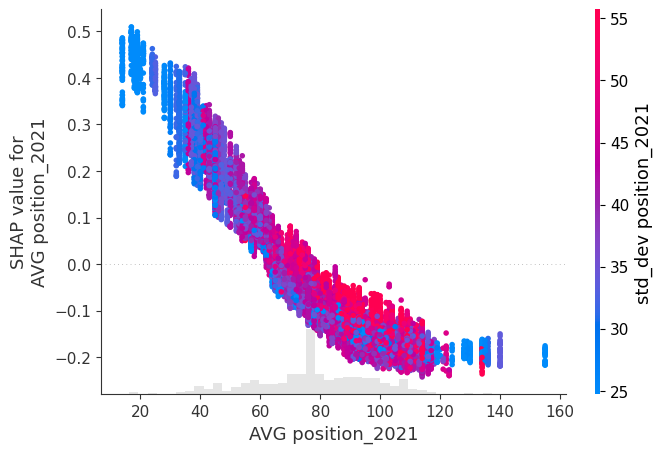

In [29]:
# Plot the scatter plot of the SHAP values for the feature 'AVG position_2021' and the feature 'std_dev position_2021'
shap.plots.scatter(shap_values_exp[:, "AVG position_2021"], color=shap_values_exp[:, "std_dev position_2021"])

- This scatterplot shows that cyclists with a very low AVG position have also a low standard deviation with a very high SHAP value for the 1 class. Also those cyclists with very high AVG position have a low standard deviation but, in this situation, there is a contribution toward the 0 class. 
- Actually those cyclists with a high standard deviation of the positions are those with an AVG position in the central part of the distribution; in this situation the standard deviation may influence the final classification, in particular high variability in the results may contribute to be classified to the 0 class.
- We can observe that for low values of the avg position there is a more evident vertical dispersion of points suggesting that, in this case, the final prevision is more dependend also on the other features.

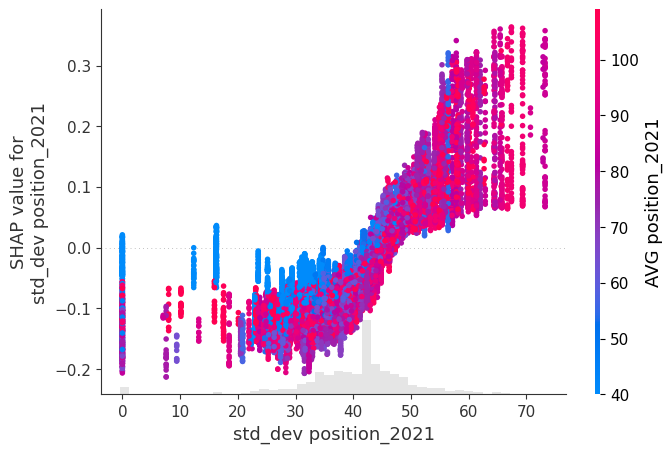

In [30]:
# Plot the scatter plot of the SHAP values for the feature 'AVG position_2021' and the feature 'std_dev position_2021'
shap.plots.scatter(shap_values_exp[:, "std_dev position_2021"], color=shap_values_exp[:, "AVG position_2021"])

The plot confirms that for cyclists with a low AVG position, the role of the contribution of this feature is typically very small (between 0.05/0.1). For those cases with a high std_dev, there is an important vertical dispersion of the contribution, suggesting that there is also a role for other features.

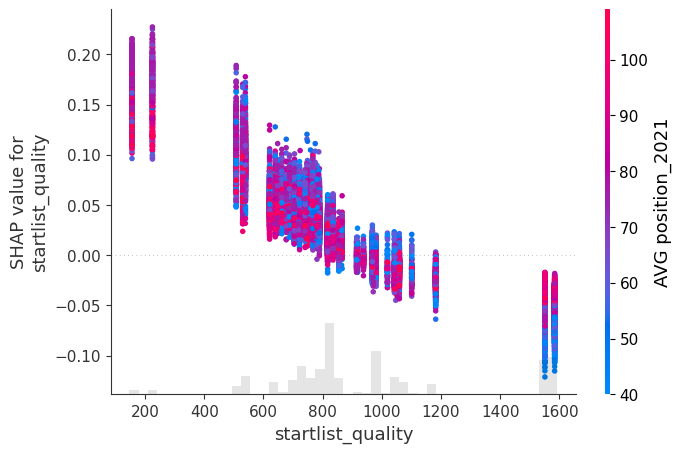

In [31]:
# Plot the scatter plot of the SHAP values for the feature 'AVG position_2021' and the feature 'std_dev position_2021'
shap.plots.scatter(shap_values_exp[:, "startlist_quality"], color=shap_values_exp[:, "AVG position_2021"])

This visualisation confirms that 'start list quality' has a medium impact on the final prediction, but the vertical spread tells us that there is an interaction with other features. In particular, the highest contribution to the top20 class is obtained for the placings in races with low prestige, which typically attract fewer participants who are not so valuable (high average position). For those races with a medium startlist quality (around 600-1100) the feature contribution is almost irrelevant. In the races of high quality there is a small contribution toward the 'non top20' class, especially for those cyclists with a low avg position.

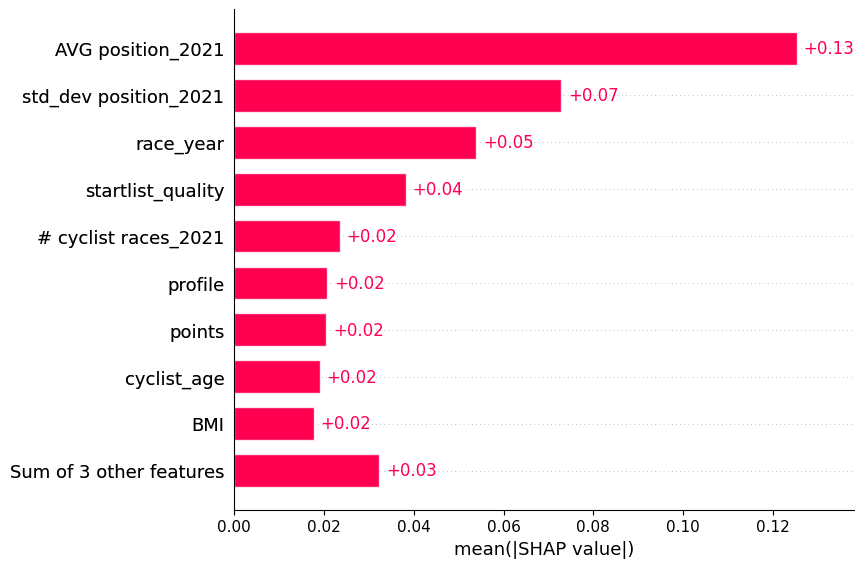

In [32]:
# Plot the bar plot of the SHAP values (Absolute values)
shap.plots.bar(shap_values_exp)

Also this visualization confirms that the feature that contributes the most to the prediction is the 'AVG position_2021' feature.

In [33]:
distributional_explanations=pd.DataFrame(shap_values_exp.values, columns=test_set.columns.tolist())
distributional_explanations

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
0,-0.042974,-0.047853,0.053874,0.010602,-0.006988,0.024562,0.057127,-0.005038,0.131346,0.023900,0.123660,-0.015590
1,0.023031,0.002049,0.027060,0.016262,-0.006055,0.017296,0.076689,0.010607,-0.123723,-0.016199,0.074372,0.013847
2,0.017181,-0.016551,0.030208,-0.008231,0.014129,0.002809,0.066707,-0.000191,0.284357,-0.000301,0.010700,0.008288
3,0.019777,0.018115,0.006663,0.002479,-0.005251,0.004989,0.058143,0.016688,0.438739,-0.016684,-0.032469,0.010119
4,0.001408,-0.012432,-0.018025,-0.002970,-0.029506,0.010999,0.052971,-0.009547,-0.179718,-0.080433,0.038486,-0.005393
...,...,...,...,...,...,...,...,...,...,...,...,...
32581,-0.007978,-0.035062,0.002536,-0.009815,0.000315,0.010749,-0.024423,-0.013510,-0.089604,-0.006136,-0.067734,-0.003885
32582,-0.007092,-0.047791,0.003528,-0.005669,0.005082,0.005035,-0.021317,-0.024759,-0.091937,0.002643,-0.053314,-0.001185
32583,0.009668,-0.041306,0.027949,-0.015735,0.035284,0.003592,0.006529,-0.018433,0.118395,-0.017606,-0.041642,0.006650
32584,-0.005622,-0.020661,0.006400,0.006630,-0.028284,0.001530,-0.004776,-0.008894,-0.012758,-0.062457,-0.088762,-0.003207


Text(0, 0.5, '')

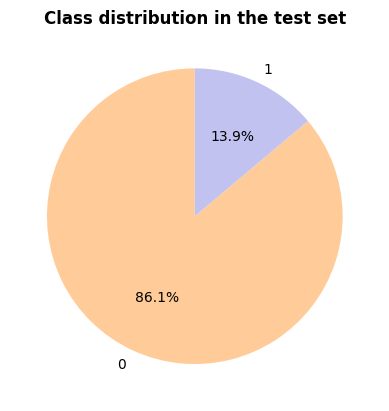

In [34]:
test_label.value_counts().plot.pie(autopct='%1.1f%%', labels=['0', '1'], colors=["#ffcc99", "#c2c2f0"], startangle=90)
plt.title("Class distribution in the test set", fontweight='bold')
plt.ylabel('')

In [35]:
distributional_explanations.describe().drop("count", axis="rows")

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
mean,-0.008128,-0.053219,0.007508,-0.007954,-0.009874,-0.005716,0.013909,-0.009306,-0.036149,-0.018008,-0.028215,-0.002260
std,0.029591,0.030077,0.023075,0.015994,0.022008,0.030497,0.049197,0.021384,0.145801,0.026043,0.084448,0.006678
min,-0.202636,-0.157534,-0.106029,-0.250071,-0.212282,-0.239376,-0.121174,-0.105650,-0.242598,-0.168554,-0.212884,-0.045786
25%,-0.013846,-0.075518,-0.008321,-0.011804,-0.018215,-0.017298,-0.014109,-0.020784,-0.141914,-0.034330,-0.084064,-0.005491
50%,0.002537,-0.052332,0.006636,-0.006583,-0.008497,-0.000066,0.013137,-0.008893,-0.073689,-0.013352,-0.045921,-0.002479
75%,0.009126,-0.030225,0.027626,-0.002501,0.000250,0.010423,0.038142,0.001599,0.019321,0.000993,0.018277,0.000842
max,0.045999,0.065771,0.106410,0.087106,0.141170,0.112940,0.227183,0.100285,0.509609,0.063781,0.363474,0.074460


We notice that almost all the features have a negative mean contribution, caused by the fact that most of the test data is classified as 0.
The features _'AVG position_2021'_ and _'std_dev position_2021'_ are those with the highest maximum value, which means that for some instances those features had an important influence on the final prediction of class '1' (0.5 and 0.3 respectively). This observation is also confirmed by the highest standard deviation and range. The feature 'geo area' has the least standard deviation, confirming that is not a discriminative feature for the final prediction.


In [36]:
#REMOVE COMMENTS TO EXTRACT SINGLE PLOTS

# for column in distributional_explanations.columns:
#     plt.figure(figsize=(6, 4))
#     sbn.kdeplot(data=distributional_explanations, x=column)
#     plt.title(f"KDE Plot for the SHAP values of {column}", fontweight="bold")
#     plt.xlabel(column)
#     plt.ylabel("Density")
#     plt.grid(True)
#     plt.show()
#     plt.close()

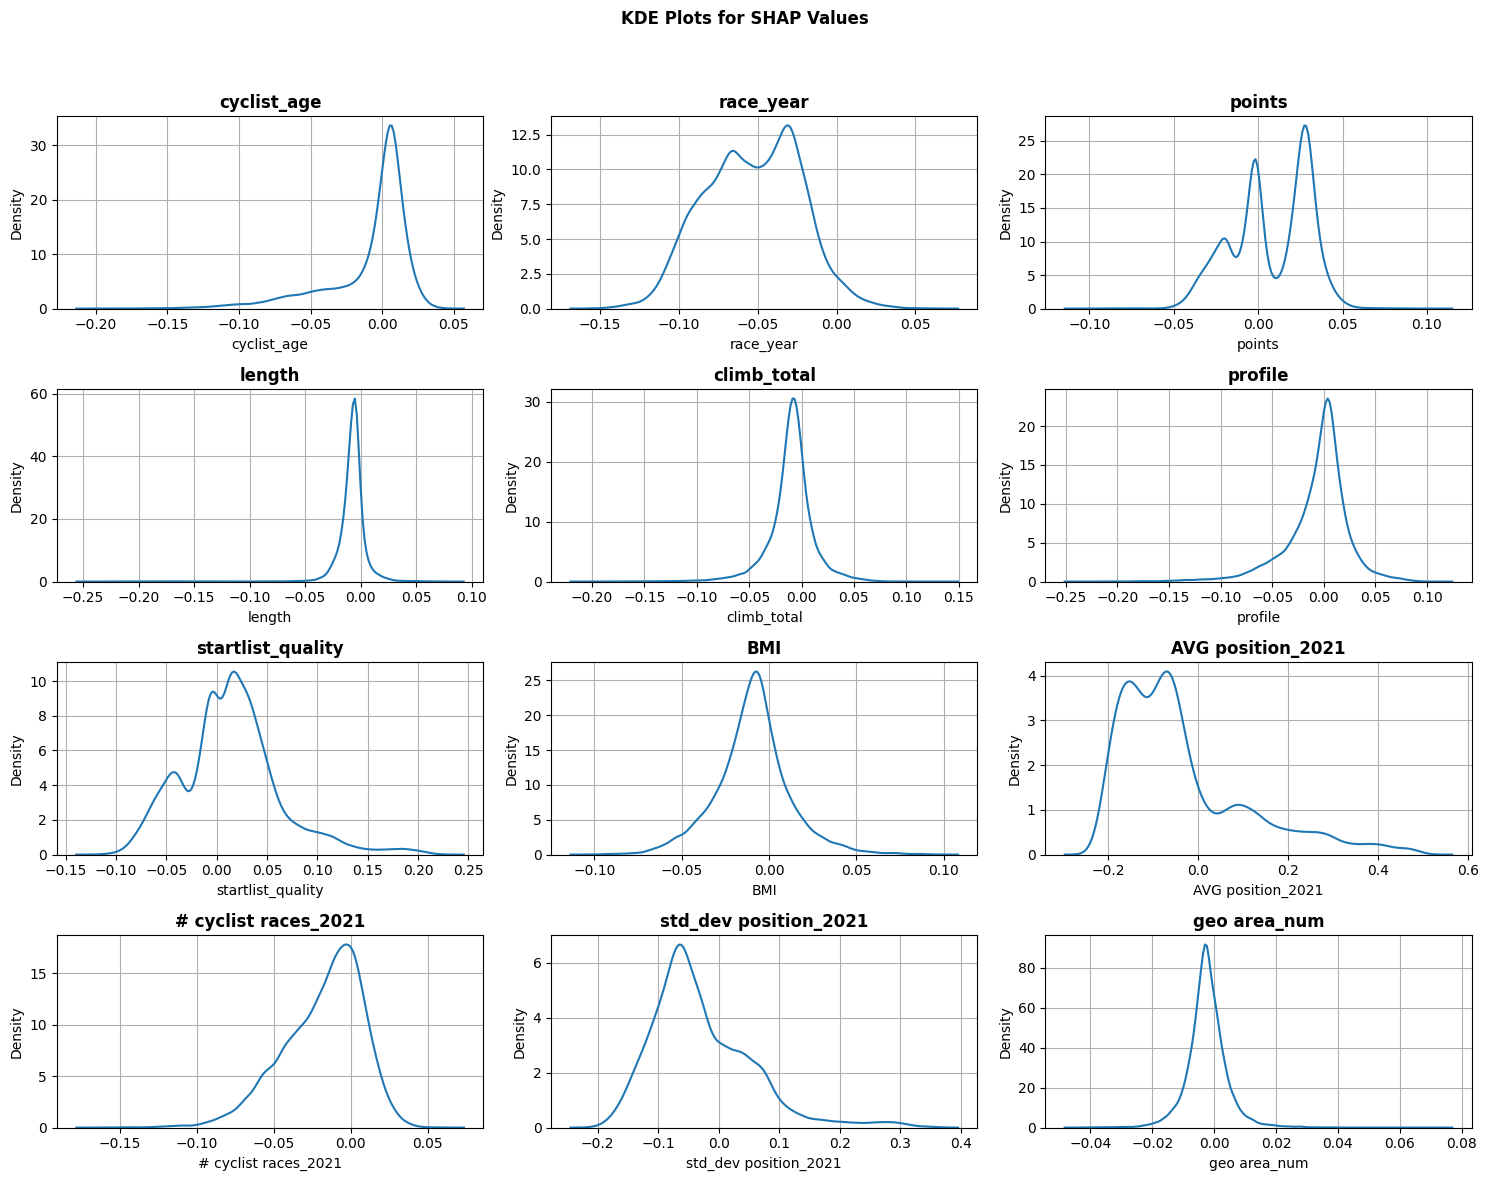

In [37]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Converts a 2D grid in a 1D array to iterate

for i, column in enumerate(distributional_explanations.columns):
    sbn.kdeplot(data=distributional_explanations, x=column, ax=axes[i])
    axes[i].set_title(f"{column}", fontweight="bold")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Density")
    axes[i].grid(True)

fig.suptitle("KDE Plots for SHAP Values",fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Also this visualization confirms that the SHAP values are centered around 0, but the distribution are not symmetric. The distribution of the SHAP values is not uniform across the features, and some features have a higher variance than others.

#### Validation
To validate this feature as the most relevant for the classification model, we check its sensitivity to perturbations.

In [39]:
mean_absolute_importances = distributional_explanations.abs().mean() #absolute value required because contributions have a sign +/-
features_by_importance = distributional_explanations.columns[mean_absolute_importances.argsort()].tolist()
features_by_importance
#AVG position_2021 is the most important feature

['geo area_num',
 'length',
 'climb_total',
 'BMI',
 'cyclist_age',
 'points',
 'profile',
 '# cyclist races_2021',
 'startlist_quality',
 'race_year',
 'std_dev position_2021',
 'AVG position_2021']

In [40]:
print_report(train_label=train_label_os, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.94      0.93    402429
       top20       0.90      0.87      0.89    269627

    accuracy                           0.91    672056
   macro avg       0.91      0.90      0.91    672056
weighted avg       0.91      0.91      0.91    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.92      0.91     28066
       top20       0.46      0.43      0.44      4520

    accuracy                           0.85     32586
   macro avg       0.68      0.67      0.68     32586
weighted avg       0.85      0.85      0.85     32586



Let's generate a series of perturbated test set, in which we add a noise of different magnitude to the test instances, and let's see how the model performance changes.

In [41]:
validation = classification_report(test_label, test_pred_rf, output_dict=True)
validation = pd.DataFrame(validation)
validation

,0,1,accuracy,macro avg,weighted avg
precision,0.908498,0.457422,0.850304,0.682960,0.845930
recall,0.918727,0.425442,0.850304,0.672085,0.850304
f1-score,0.913584,0.440853,0.850304,0.677219,0.848012
support,28066.000000,4520.000000,0.850304,32586.000000,32586.000000


In [42]:
# Generates an array of noise in the range [0, 1] with the same shape as the test set
random_noise = np.random.rand(test_set.shape[0],) # Random noise from a normal distribution

# We generate a list of noise magnitudes to test from (0.1, 0.2, ..., 0.9)
noise_magnitudes = [eps / 10 for eps in range(1, 10)]

We expect that adding a random noise to the relevant feature will have an impact on performance of the classifier. So we follow this strategy:
- First, we generate artificial noise on the test data.
- Then we predict the perturbed test data using the Random Forest classifier.
- We compare the evaluation metrics of the classifier applied to the original and the perturbed test set.

In [43]:
features_by_importance.remove("profile")
features_by_importance.remove("geo area_num")

Notice that the corruption on the attribute 'geo area_num' are not so meaningful, since this column is an encoding of a categorical feature. The same reasoning applies to the 'profile' feature, which is an ordinal.

In [44]:
features_by_importance

['length',
 'climb_total',
 'BMI',
 'cyclist_age',
 'points',
 '# cyclist races_2021',
 'startlist_quality',
 'race_year',
 'std_dev position_2021',
 'AVG position_2021']

In [45]:
corruptions_by_feature_and_noise = dict()
for feature in features_by_importance:
    for noise_magnitude in noise_magnitudes:
        corruptions_by_feature_and_noise[(feature, noise_magnitude)] = test_set.copy()
        corruptions_by_feature_and_noise[(feature, noise_magnitude)][feature] += random_noise * noise_magnitude

In [46]:
validations_by_feature_and_noise = dict()
for (feature, noise), corruption in corruptions_by_feature_and_noise.items():
    validations_by_feature_and_noise[(feature, noise)] = classification_report(test_label, rf.predict(corruption), output_dict=True)

In [47]:
metric = "f1-score"
corruption_validation = pd.DataFrame([
    (feature, noise_magnitude, validations_by_feature_and_noise[(feature, noise_magnitude)]["weighted avg"][metric], "shap")
    for feature, noise_magnitude in validations_by_feature_and_noise
    ],
    columns=["feature", "noise_magnitude", "performance", "algorithm"]
)
corruption_validation["difference"] = corruption_validation["performance"] - validation["weighted avg"][metric]

In [48]:
pd.set_option('display.max_rows', None) 
corruption_validation

,feature,noise_magnitude,performance,algorithm,difference
0,length,0.1,0.848044,shap,0.000032
1,length,0.2,0.848082,shap,0.000071
2,length,0.3,0.848082,shap,0.000071
3,length,0.4,0.848082,shap,0.000071
4,length,0.5,0.848082,shap,0.000071
5,length,0.6,0.848082,shap,0.000071
6,length,0.7,0.848082,shap,0.000071
7,length,0.8,0.848082,shap,0.000071
8,length,0.9,0.848082,shap,0.000071
9,climb_total,0.1,0.847988,shap,-0.000024


In [49]:
noise_magnitudes = [2 ** eps for eps in range(0, 6)]  # Increase the magnitude of the noise: 1, 2, 4, 8, 16, 32

In [50]:
corruptions_by_feature_and_noise = dict()
for feature in features_by_importance:
    for noise_magnitude in noise_magnitudes:
        corruptions_by_feature_and_noise[(feature, noise_magnitude)] = test_set.copy()
        corruptions_by_feature_and_noise[(feature, noise_magnitude)][feature] += random_noise * noise_magnitude
validations_by_feature_and_noise = dict()
for (feature, noise), corruption in corruptions_by_feature_and_noise.items():
    validations_by_feature_and_noise[(feature, noise)] = classification_report(test_label, rf.predict(corruption), output_dict=True)
metric = "f1-score"
corruption_validation = pd.DataFrame([
    (feature, noise_magnitude, validations_by_feature_and_noise[(feature, noise_magnitude)]["weighted avg"][metric], "shap")
    for feature, noise_magnitude in validations_by_feature_and_noise
    ],
    columns=["feature", "noise_magnitude", "performance", "algorithm"]
)
corruption_validation["difference"] = corruption_validation["performance"] - validation["weighted avg"][metric]    

In [51]:
corruption_validation

,feature,noise_magnitude,performance,algorithm,difference
0,length,1,0.848082,shap,0.000071
1,length,2,0.848082,shap,0.000071
2,length,4,0.848082,shap,0.000071
3,length,8,0.848082,shap,0.000071
4,length,16,0.848082,shap,0.000071
5,length,32,0.848082,shap,0.000071
6,climb_total,1,0.847949,shap,-0.000062
7,climb_total,2,0.847949,shap,-0.000062
8,climb_total,4,0.847926,shap,-0.000086
9,climb_total,8,0.847948,shap,-0.000064


In [52]:
pd.reset_option('display.max_rows')

It can be seen that by increasing the amount of noise, the performance of the model decreases, especially for the feature 'AVG position_2021'. This is to be expected as the noise is added to the most important features according to the SHAP values. Actually, in the first attempt to add noise, there was no significant decrease in performance for the most relevant feature. This may be because the model itself is more robust to noise (as in the case of ensemble methods) or because the noise added was too small.

In [53]:
corruption_validation.groupby("feature").describe()[["performance", "difference"]]

performance                                          \
                            count      mean       std       min       25%   
feature                                                                     
# cyclist races_2021          6.0  0.847520  0.000391  0.846885  0.847329   
AVG position_2021             6.0  0.844937  0.005413  0.834806  0.843830   
BMI                           6.0  0.841727  0.003577  0.838138  0.839097   
climb_total                   6.0  0.847931  0.000032  0.847868  0.847930   
cyclist_age                   6.0  0.845995  0.003394  0.840782  0.843802   
length                        6.0  0.848082  0.000000  0.848082  0.848082   
points                        6.0  0.847989  0.000129  0.847747  0.848012   
race_year                     6.0  0.848012  0.000000  0.848012  0.848012   
startlist_quality             6.0  0.847869  0.000165  0.847609  0.847777   
std_dev position_2021         6.0  0.818263  0.039069  0.747675  0.806019   

                                                    difference            \
                            50%       75%       max      count      mean   
feature                                                                    
# cyclist races_2021   0.847622  0.847835  0.847857        6.0 -0.000491   
AVG position_2021      0.847443  0.848274  0.848751        6.0 -0.003075   
BMI                    0.840528  0.844756  0.846381        6.0 -0.006285   
climb_total            0.847946  0.847949  0.847949        6.0 -0.000081   
cyclist_age            0.847355  0.848501  0.848978        6.0 -0.002017   
length                 0.848082  0.848082  0.848082        6.0  0.000071   
points                 0.848012  0.848012  0.848140        6.0 -0.000023   
race_year              0.848012  0.848012  0.848012        6.0  0.000000   
startlist_quality      0.847915  0.847986  0.848035        6.0 -0.000142   
std_dev position_2021  0.835644  0.844554  0.846945        6.0 -0.029749   

                                                                         \
                            std       min       25%       50%       75%   
feature                                                                   
# cyclist races_2021   0.000391 -0.001126 -0.000682 -0.000390 -0.000177   
AVG position_2021      0.005413 -0.013206 -0.004182 -0.000568  0.000263   
BMI                    0.003577 -0.009874 -0.008915 -0.007484 -0.003255   
climb_total            0.000032 -0.000143 -0.000081 -0.000066 -0.000063   
cyclist_age            0.003394 -0.007229 -0.004210 -0.000657  0.000490   
length                 0.000000  0.000071  0.000071  0.000071  0.000071   
points                 0.000129 -0.000264  0.000000  0.000000  0.000000   
race_year              0.000000  0.000000  0.000000  0.000000  0.000000   
startlist_quality      0.000165 -0.000403 -0.000235 -0.000097 -0.000025   
std_dev position_2021  0.039069 -0.100337 -0.041992 -0.012368 -0.003458   

                                 
                            max  
feature                          
# cyclist races_2021  -0.000155  
AVG position_2021      0.000740  
BMI                   -0.001631  
climb_total           -0.000062  
cyclist_age            0.000966  
length                 0.000071  
points                 0.000128  
race_year              0.000000  
startlist_quality      0.000024  
std_dev position_2021 -0.001066

In [54]:
corruption_validation.groupby("noise_magnitude").describe()[["performance", "difference"]]

performance                                                    \
                      count      mean       std       min       25%       50%   
noise_magnitude                                                                 
1                      10.0  0.847840  0.000687  0.846381  0.847880  0.848000   
2                      10.0  0.847594  0.001026  0.845617  0.847851  0.848012   
4                      10.0  0.846777  0.002771  0.841363  0.847454  0.847997   
8                      10.0  0.844876  0.005883  0.829925  0.846403  0.847247   
16                     10.0  0.841062  0.015440  0.798050  0.842888  0.847797   
32                     10.0  0.834846  0.031018  0.747675  0.838799  0.847586   

                                    difference                                \
                      75%       max      count      mean       std       min   
noise_magnitude                                                                
1                0.848065  0.848751       10.0 -0.000172  0.000687 -0.001631   
2                0.848071  0.848529       10.0 -0.000418  0.001026 -0.002394   
4                0.848065  0.848978       10.0 -0.001235  0.002771 -0.006649   
8                0.847996  0.848082       10.0 -0.003136  0.005883 -0.018086   
16               0.847976  0.848140       10.0 -0.006950  0.015440 -0.049961   
32               0.847920  0.848082       10.0 -0.013166  0.031018 -0.100337   

                                                         
                      25%       50%       75%       max  
noise_magnitude                                          
1               -0.000132 -0.000012  0.000053  0.000740  
2               -0.000161  0.000000  0.000059  0.000517  
4               -0.000557 -0.000015  0.000053  0.000966  
8               -0.001609 -0.000765 -0.000016  0.000071  
16              -0.005124 -0.000215 -0.000036  0.000128  
32              -0.009213 -0.000425 -0.000092  0.000071

As expected, the higher the noise, the worse the performance.

### LIME: Local Interpretability Model-agnostic Explanations

In [55]:
# %pip install interpret lime

In [56]:
from interpret import set_visualize_provider
from interpret.provider import InlineProvider
from interpret import show
from tqdm import tqdm
from interpret.blackbox import LimeTabular

In [57]:
set_visualize_provider(InlineProvider())

In [58]:
rf_explainer_lime = LimeTabular(rf, train_set_os, mode="classification")

In [59]:
# The explainer requires the classification label to be in the data set.
temp_train_set_os=train_set_os.merge(train_label_os, left_index=True, right_index=True)

In [60]:
temp_train_set_os

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num,top20
0,24,1970,225,240000,2611,2,372,22.057578,13.0,37.0,18.685480,7,1
1,26,1970,225,240000,2611,2,372,18.646937,10.0,10.0,8.141116,7,1
2,23,1970,225,240000,2611,2,372,22.840000,16.0,67.0,18.234961,7,1
3,24,1970,225,240000,2611,2,372,21.748939,7.0,38.0,7.836705,7,1
4,23,1970,225,240000,2611,2,372,22.727257,20.0,7.0,9.860938,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
672051,26,1989,100,240000,3500,2,1849,20.554507,97.0,118.0,46.498770,7,1
672052,27,2008,80,145500,2446,2,1101,20.800000,69.0,457.0,40.888097,7,1
672053,25,1985,80,124000,3500,5,925,21.890000,32.0,417.0,32.394122,6,1
672054,27,1979,100,189000,2360,2,1381,20.879058,46.0,177.0,33.895912,7,1


**500 Samples**

In [61]:
# # Select 500 rows
# stratified_sample, _ = train_test_split(temp_train_set_os, train_size=500, stratify=temp_train_set_os["top20"], random_state=RANDOM_STATE)

# # Drop the label
# stratified_labels=stratified_sample.pop("top20")

# print(stratified_sample.shape)
# print(stratified_labels.shape)

In [62]:
# lime_explanations = np.array([np.array(e["scores"])
#                                     for e in tqdm(rf_explainer_lime.explain_local(stratified_sample, stratified_labels)._internal_obj["specific"])])

In [63]:
#dump(lime_explanations, "XAI_computations/lime_explanations_500.joblib")

In [64]:
# lime_explanations = load("XAI_computations/lime_explanations_500.joblib")

In [65]:
#lime_explanations

In [66]:
#train_set_os.shape[0]

**10000 Samples**

In [67]:
# # Select 10000 rows
# stratified_sample, _ = train_test_split(temp_train_set_os, train_size=10000, stratify=temp_train_set_os["top20"], random_state=RANDOM_STATE)

# # Drop the label
# stratified_labels=stratified_sample.pop("top20")

# print(stratified_sample.shape)
# print(stratified_labels.shape)

In [68]:
# lime_explanations = np.array([np.array(e["scores"])
#                                     for e in tqdm(rf_explainer_lime.explain_local(stratified_sample, stratified_labels)._internal_obj["specific"])])

In [69]:
#dump(lime_explanations, "XAI_computations/lime_explanations_10000.joblib")

In [70]:
#lime_explanations=load("XAI_computations/lime_explanations_10000.joblib")

In [71]:
# metric = "f1-score"
# corruption_validation_lime = pd.DataFrame([
#     (feature, noise_magnitude, validations_by_feature_and_noise[(feature, noise_magnitude)]["weighted avg"][metric], "lime")
#     for feature, noise_magnitude in validations_by_feature_and_noise
#     ],
#     columns=["feature", "noise_magnitude", "performance", "algorithm"]
# )
# corruption_validation_lime["difference"] = corruption_validation_lime["performance"] - validation["weighted avg"][metric]

# corruption_validation = pd.concat((corruption_validation, corruption_validation_lime))
# corruption_validation_lime

In [72]:
#corruption_validation

**50000 Samples**

In [73]:
temp_test_set = test_set.copy()

print(test_set.shape)

(50000, 12)
(50000,)


In [74]:
lime_explanations = np.array([np.array(e["scores"])
                                    for e in tqdm(rf_explainer_lime.explain_local(temp_test_set, test_label)._internal_obj["specific"])])

In [75]:
dump(lime_explanations, "XAI_computations/lime_explanations.joblib")

In [76]:
lime_explanations=load("XAI_computations/lime_explanations.joblib")

In [77]:
lime_explanations

array([[ 0.27896992,  0.26632583, -0.11590135, ..., -0.01635223,
         0.00946891,  0.00918616],
       [ 0.07207039, -0.05253959,  0.03741255, ...,  0.00693619,
         0.0044073 , -0.00121736],
       [-0.09695661, -0.08937683, -0.07826373, ...,  0.01027756,
         0.0102328 ,  0.0097723 ],
       ...,
       [ 0.26248312,  0.13638172, -0.08563352, ..., -0.01857183,
         0.01534701,  0.00932478],
       [ 0.28474009,  0.26829464, -0.11417724, ..., -0.00727841,
         0.00719826,  0.0047097 ],
       [ 0.08403841, -0.0690186 , -0.04854126, ...,  0.00692733,
         0.00616021,  0.00225363]])

In [78]:
lime_explanations.shape

(50000, 10)

In [79]:
metric = "f1-score"
corruption_validation_lime = pd.DataFrame([
    (feature, noise_magnitude, validations_by_feature_and_noise[(feature, noise_magnitude)]["weighted avg"][metric], "lime")
    for feature, noise_magnitude in validations_by_feature_and_noise
    ],
    columns=["feature", "noise_magnitude", "performance", "algorithm"]
)
corruption_validation_lime["difference"] = corruption_validation_lime["performance"] - validation["weighted avg"][metric]

corruption_validation = pd.concat((corruption_validation, corruption_validation_lime))
corruption_validation_lime

,feature,noise_magnitude,performance,algorithm,difference
0,length,1,0.848082,lime,0.000071
1,length,2,0.848082,lime,0.000071
2,length,4,0.848082,lime,0.000071
3,length,8,0.848082,lime,0.000071
4,length,16,0.848082,lime,0.000071
5,length,32,0.848082,lime,0.000071
6,climb_total,1,0.847949,lime,-0.000062
7,climb_total,2,0.847949,lime,-0.000062
8,climb_total,4,0.847926,lime,-0.000086
9,climb_total,8,0.847948,lime,-0.000064


Also for this algoritmh the two features 'AVG position' e 'std_dev position' are those for which a perturbation is more impactful.

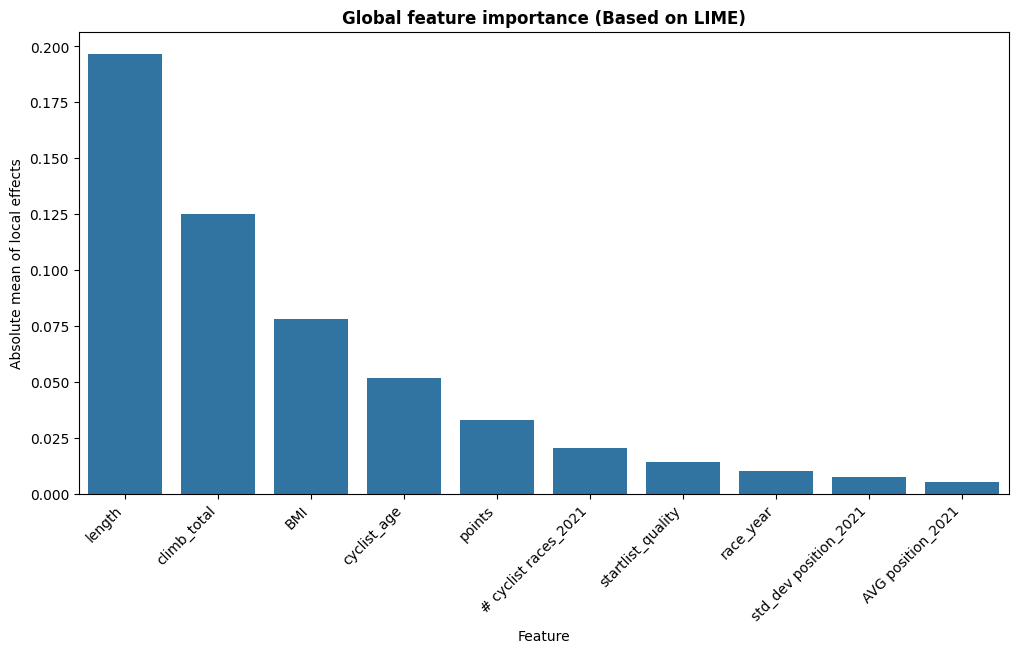

In [84]:
lime_df = pd.DataFrame(lime_explanations, columns=train_set_os.columns.tolist())

# Determine the global importance (abs mean of the local effects)
global_importance = lime_df.abs().mean().sort_values(ascending=False)
feature_names = global_importance.index.tolist()

plt.figure(figsize=(12, 6))
sbn.barplot(x=feature_names[:len(global_importance)], y=global_importance.values)
plt.title("Global feature importance (Based on LIME)", fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("Absolute mean of local effects")
plt.xticks(rotation=45, ha='right')
plt.show()

In terms of feature contribution according to the LIME approach, we notice that the 'AVG position' and the 'std_dev' are the less important for a localised interpretability. This visualisation highlights that in some cases (here only a subset of the total test dataset), features such as the race characteristics or the age/BMI of the cyclist are more influential.

## Local interpretability

### LORE: LOcal Rule-based Explanation

In [85]:
#%pip install XAI-Library

In [86]:
from xailib.explainers.lore_explainer import LoreTabularExplainer

explanation_algorithm = LoreTabularExplainer(rf)
configuration = {
    "neigh_type": "rndgen",
    "size": 1000,
    "ocr": 0.1,
    "ngen": 100
}

lore_train_data = pd.concat((train_set_os, train_label_os), axis="columns")
explanation_algorithm.fit(lore_train_data, "top20", config=configuration)

Let's considers some instances to evaluate how the classification procedure is done. 

In [ ]:
pd.DataFrame(test_set.iloc[0].values.reshape(1, -1), columns=test_set.columns)

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
0,24.0,1970.0,225.0,240000.0,2611.0,2.0,372.0,22.057578,13.0,37.0,18.68548,7.0


In [87]:
explanation = explanation_algorithm.explain(test_set.iloc[0].values)

In [90]:
dump(explanation, "XAI_computations/lore_expl_1.joblib")

['XAI_computations/lore_expl_1.joblib']

In [91]:
explanation=load("XAI_computations/lore_expl_1.joblib")

In [92]:
# extract decision rule for the given instance
explanation.getRules()

{'premise': [{'att': 'AVG position_2021',
   'op': '<=',
   'thr': 30.5,
   'is_continuous': True},
  {'att': 'startlist_quality',
   'op': '<=',
   'thr': 1042.0,
   'is_continuous': True}],
 'cons': 1,
 'class_name': 'top20'}

**Decision Rule for this instance**
$$
\begin{array}{l l l}
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 30.5 \\
\text{startlist\_quality} & \leq & 1042.0 \\
\end{array}
$$

$ \textbf{Consequent:} 1 \\ $
$ \text{Class: top20} $


In [93]:
# extract counterfactual explanation
explanation.getCounterfactualRules()

[{'premise': [{'att': 'AVG position_2021',
    'op': '<=',
    'thr': 82.5,
    'is_continuous': True},
   {'att': 'AVG position_2021', 'op': '>', 'thr': 40.5, 'is_continuous': True},
   {'att': 'race_year', 'op': '<=', 'thr': 1988.5, 'is_continuous': True},
   {'att': 'startlist_quality',
    'op': '>',
    'thr': 1399.5,
    'is_continuous': True},
   {'att': 'BMI',
    'op': '<=',
    'thr': 23.547308921813965,
    'is_continuous': True}],
  'cons': 0,
  'class_name': 'top20'},
 {'premise': [{'att': 'AVG position_2021',
    'op': '>',
    'thr': 50.5,
    'is_continuous': True},
   {'att': 'race_year', 'op': '>', 'thr': 1994.5, 'is_continuous': True},
   {'att': 'std_dev position_2021',
    'op': '<=',
    'thr': 46.667423248291016,
    'is_continuous': True},
   {'att': 'BMI',
    'op': '<=',
    'thr': 23.83506202697754,
    'is_continuous': True}],
  'cons': 0,
  'class_name': 'top20'},
 {'premise': [{'att': 'AVG position_2021',
    'op': '<=',
    'thr': 50.5,
    'is_continuous

**COUNTERFACTUALS**

----------
**Counterfactual Rule 1**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 82.5 \\
\text{AVG position\_2021} & > & 40.5 \\
\text{race\_year} & \leq & 1988.5 \\
\text{startlist\_quality} & > & 1399.5 \\
\text{BMI} & \leq & 23.547308921813965 \\
\hline
\end{array}
$$

$\textbf{Consequent:} 0$

----------
**Counterfactual Rule 2**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & > & 50.5 \\
\text{race\_year} & > & 1994.5 \\
\text{std\_dev position\_2021} & \leq & 46.667423248291016 \\
\text{BMI} & \leq & 23.83506202697754 \\
\hline
\end{array}
$$

$\textbf{Consequent:} 0$

----------
**Counterfactual Rule 3**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 50.5 \\
\text{AVG position\_2021} & > & 40.5 \\
\text{race\_year} & > & 1994.5 \\
\text{std\_dev position\_2021} & \leq & 46.667423248291016 \\
\text{profile} & \leq & 2.5 \\
\text{length} & > & 144750.0 \\
\hline
\end{array}
$$

$\textbf{Consequent:} 0$

----------
**Counterfactual Rule 4**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & > & 40.5 \\
\text{race\_year} & \leq & 1994.5 \\
\text{race\_year} & > & 1988.5 \\
\text{std\_dev position\_2021} & \leq & 36.2630729675293 \\
\text{points} & > & 90.0 \\
\text{cyclist\_age} & \leq & 37.0 \\
\# \text{ cyclist races\_2021} & \leq & 238.0 \\
\text{geo area\_num} & > & 3.5 \\
\hline
\end{array}
$$

$\textbf{Consequent:} 0$

----------

In [94]:
explanation.plotRules()

In [95]:
explanation.expDict["fidelity"]

0.9921655021138968

In general the **fidelity** is a measure of  refers to how well an explanation or an interpretable model represents the behavior of the original model. So it measures how well an explanation or a surrogate model matches the "decision-making" process of the original model. In this case we obtained a very high score.

In [96]:
#explanation = explanation_algorithm.explain(train_set_os.iloc[560].values)

In [97]:
#dump(explanation, "XAI_computations/lore_expl_2.joblib")

['XAI_computations/lore_expl_2.joblib']

In [98]:
explanation=load("XAI_computations/lore_expl_2.joblib")

In [ ]:
train_set_os.iloc[560]

cyclist_age                  26.000000
race_year                  1970.000000
points                      125.000000
length                   195000.000000
climb_total                1456.000000
profile                       1.000000
startlist_quality           430.000000
BMI                          18.467731
AVG position_2021            13.000000
# cyclist races_2021         18.000000
std_dev position_2021        13.227151
geo area_num                  7.000000
Name: 560, dtype: float64

In [99]:
explanation.getRules()

{'premise': [{'att': 'AVG position_2021',
   'op': '<=',
   'thr': 45.5,
   'is_continuous': True},
  {'att': 'startlist_quality',
   'op': '<=',
   'thr': 875.5,
   'is_continuous': True},
  {'att': '# cyclist races_2021',
   'op': '>',
   'thr': 33.0,
   'is_continuous': True},
  {'att': 'race_year', 'op': '<=', 'thr': 2007.5, 'is_continuous': True},
  {'att': 'climb_total', 'op': '<=', 'thr': 4110.0, 'is_continuous': True}],
 'cons': 1,
 'class_name': 'top20'}

**Decision Rule:**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 45.5 \\
\text{startlist\_quality} & \leq & 875.5 \\
\# \text{cyclist races\_2021} & > & 33.0 \\
\text{race\_year} & \leq & 2007.5 \\
\text{climb\_total} & \leq & 4110.0 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 1 \\$
$ \textbf{Class: top20} $


In [ ]:
explanation.plotRules()

In [100]:
explanation.getCounterfactualRules()

[{'premise': [{'att': 'AVG position_2021',
    'op': '>',
    'thr': 74.5,
    'is_continuous': True},
   {'att': 'race_year', 'op': '<=', 'thr': 1995.5, 'is_continuous': True},
   {'att': 'points', 'op': '>', 'thr': 65.0, 'is_continuous': True},
   {'att': 'std_dev position_2021',
    'op': '<=',
    'thr': 46.190786361694336,
    'is_continuous': True},
   {'att': 'geo area_num', 'op': '>', 'thr': 1.5, 'is_continuous': True}],
  'cons': 0,
  'class_name': 'top20'},
 {'premise': [{'att': 'AVG position_2021',
    'op': '<=',
    'thr': 45.5,
    'is_continuous': True},
   {'att': 'startlist_quality',
    'op': '<=',
    'thr': 882.5,
    'is_continuous': True},
   {'att': 'startlist_quality',
    'op': '>',
    'thr': 875.5,
    'is_continuous': True}],
  'cons': 0,
  'class_name': 'top20'},
 {'premise': [{'att': 'AVG position_2021',
    'op': '<=',
    'thr': 45.5,
    'is_continuous': True},
   {'att': 'startlist_quality',
    'op': '<=',
    'thr': 875.5,
    'is_continuous': True},

**Counterfactual Rule 1:**
$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & > & 74.5 \\
\text{race\_year} & \leq & 1995.5 \\
\text{points} & > & 65.0 \\
\text{std\_dev position\_2021} & \leq & 46.190786361694336 \\
\text{geo area\_num} & > & 1.5 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 0 \\$

----------
**Counterfactual Rule 2:**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 45.5 \\
\text{startlist\_quality} & \leq & 882.5 \\
\text{startlist\_quality} & > & 875.5 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 0 \\$

----------
**Counterfactual Rule 3:**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 45.5 \\
\text{startlist\_quality} & \leq & 875.5 \\
\# \text{cyclist races\_2021} & \leq & 33.0 \\
\text{std\_dev position\_2021} & \leq & 52.400882720947266 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 0 \\$

----------
**Counterfactual Rule 4:**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 45.5 \\
\text{startlist\_quality} & > & 1364.0 \\
\text{BMI} & \leq & 24.184999465942383 \\
\text{BMI} & > & 19.0 \\
\text{points} & > & 77.5 \\
\text{race\_year} & \leq & 1999.0 \\
\text{cyclist\_age} & > & 30.0 \\
\# \text{cyclist races\_2021} & \leq & 145.0 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 0 \\$


In [105]:
#explanation = explanation_algorithm.explain(train_set_os.iloc[20].values)

In [106]:
#dump(explanation, "XAI_computations/lore_expl_3.joblib")

['XAI_computations/lore_expl_3.joblib']

In [107]:
explanation=load("XAI_computations/lore_expl_3.joblib")

In [108]:
explanation.expDict["fidelity"]

0.9956525025088878

In [109]:
explanation.getRules()

{'premise': [{'att': 'AVG position_2021',
   'op': '<=',
   'thr': 22.5,
   'is_continuous': True},
  {'att': 'profile', 'op': '>', 'thr': 1.5, 'is_continuous': True}],
 'cons': 1,
 'class_name': 'top20'}

**Decision Rule:**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 22.5 \\
\text{profile} & > & 1.5 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 1 \\$

In [110]:
explanation.getCounterfactualRules()

[{'premise': [{'att': 'AVG position_2021',
    'op': '>',
    'thr': 73.5,
    'is_continuous': True},
   {'att': 'race_year', 'op': '<=', 'thr': 1991.5, 'is_continuous': True},
   {'att': 'points', 'op': '>', 'thr': 60.0, 'is_continuous': True},
   {'att': 'std_dev position_2021',
    'op': '<=',
    'thr': 45.62846755981445,
    'is_continuous': True},
   {'att': 'startlist_quality',
    'op': '<=',
    'thr': 475.0,
    'is_continuous': True},
   {'att': 'cyclist_age', 'op': '<=', 'thr': 25.5, 'is_continuous': True}],
  'cons': 0,
  'class_name': 'top20'},
 {'premise': [{'att': 'AVG position_2021',
    'op': '<=',
    'thr': 73.5,
    'is_continuous': True},
   {'att': 'AVG position_2021', 'op': '>', 'thr': 40.5, 'is_continuous': True},
   {'att': 'race_year', 'op': '<=', 'thr': 1991.5, 'is_continuous': True},
   {'att': 'points', 'op': '>', 'thr': 162.5, 'is_continuous': True},
   {'att': 'std_dev position_2021',
    'op': '<=',
    'thr': 45.62846755981445,
    'is_continuous': Tr

**Counterfactual Rule 1:**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & > & 73.5 \\
\text{race\_year} & \leq & 1991.5 \\
\text{points} & > & 60.0 \\
\text{std\_dev position\_2021} & \leq & 45.62846755981445 \\
\text{startlist\_quality} & \leq & 475.0 \\
\text{cyclist\_age} & \leq & 25.5 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 0 $

---

**Counterfactual Rule 2:**

$$
\begin{array}{|l|l|l|}
\hline
\textbf{Attribute} & \textbf{Operation} & \textbf{Threshold} \\
\hline
\text{AVG position\_2021} & \leq & 73.5 \\
\text{AVG position\_2021} & > & 40.5 \\
\text{race\_year} & \leq & 1991.5 \\
\text{points} & > & 162.5 \\
\text{std\_dev position\_2021} & \leq & 45.62846755981445 \\
\text{\# cyclist races\_2021} & \leq & 165.5 \\
\text{BMI} & \leq & 24.31661319732666 \\
\hline
\end{array}
$$

$ \textbf{Consequent:} 0 $


In [111]:
explanation.plotRules()